# XGBoost placement prediction

This notebook runs the Phase 3 XGBoost model using the shared Phase 2 feature columns, target encoding, split, and scaling. It does not create a second dataset or split.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.calibration import CalibrationDisplay

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)

from sklearn.preprocessing import StandardScaler


# Load dataset
df = pd.read_excel("../student_placement_phase1_ready.xlsx")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (100000, 20)


,college_pursuing_year,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,placement_status
0,4,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,72.647009,77.463863,2,63.382726,52.938240,Yes,Not Placed
1,4,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,61.699110,88.887600,1,73.694605,60.198856,No,Not Placed
2,4,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,87.396911,74.153265,0,63.329294,43.708803,No,Placed
3,4,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,58.401069,87.635955,1,47.636099,56.549154,Yes,Not Placed
4,3,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,74.489201,79.120749,1,0.000000,67.268893,No,Placed


In [4]:
features = [
    "college_pursuing_year", "cgpa", "branch", "college_tier",
    "internships_count", "projects_count", "certifications_count",
    "coding_skill_score", "aptitude_score", "communication_skill_score",
    "logical_reasoning_score", "hackathons_participated", "github_repos",
    "mock_interview_score", "attendance_percentage", "backlogs",
    "extracurricular_score", "leadership_score", "volunteer_experience",
]

X = pd.get_dummies(
    df[features],
    columns=["branch", "college_tier", "volunteer_experience"],
    drop_first=True,
).astype(float)

y = df["placement_status"].map({
    "Not Placed": 0,
    "Placed": 1
})

phase2_features = X.columns.tolist()

if y.isna().any():
    raise ValueError(
        "placement_status contains values outside the Phase 2 target encoding"
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Match Phase 2 preprocessing exactly
# Fit scaler only on training data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }, y_pred, y_prob

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
baseline_metrics, _, _ = evaluate(xgb_model)
pd.DataFrame([baseline_metrics])

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.56485,0.572055,0.792238,0.664379,0.581012


In [6]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
}


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
metrics, y_pred, y_prob = evaluate(best_xgb)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)
pd.DataFrame([metrics]).to_csv(RESULTS_PATH, index=False)
pd.DataFrame([metrics])

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation F1-score: 0.6939798327943445


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.5613,0.559037,0.914007,0.693752,0.576145


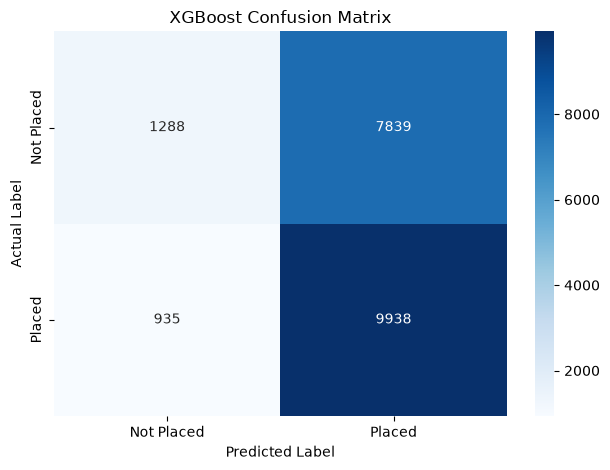

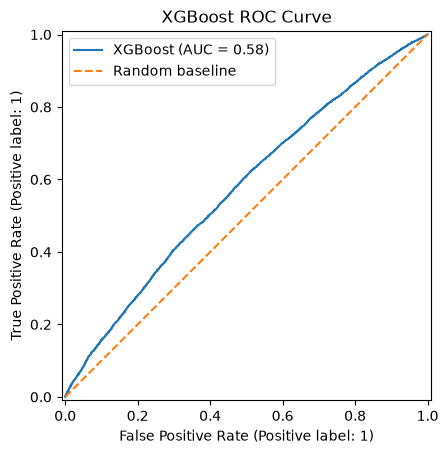

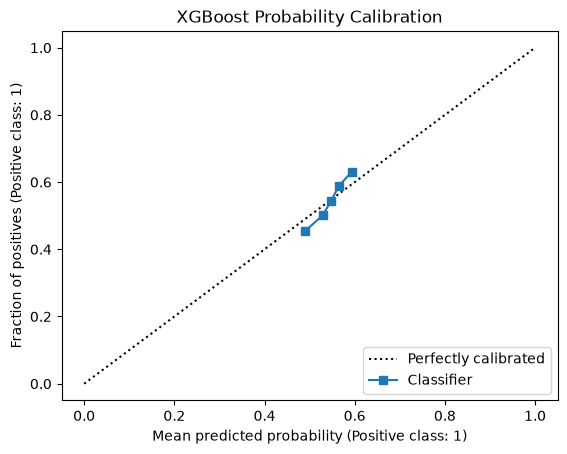

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"],
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob, name="XGBoost")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=5, strategy="quantile")
plt.title("XGBoost Probability Calibration")
plt.show()

In [9]:
importance = pd.DataFrame({
    "Feature": phase2_features,
    "Importance": best_xgb.feature_importances_,
}).sort_values("Importance", ascending=False)
importance.to_csv(IMPORTANCE_PATH, index=False)
importance.head(10)

,Feature,Importance
13,backlogs,0.231594
3,projects_count,0.124353
2,internships_count,0.121516
5,coding_skill_score,0.106067
11,mock_interview_score,0.102685
7,communication_skill_score,0.080856
8,logical_reasoning_score,0.076786
6,aptitude_score,0.072387
14,extracurricular_score,0.043465
15,leadership_score,0.040291
